# Phase 3 — Base Model Training & Comparison

**Goal:** Train the classical ML classifiers on every applicable feature representation,
evaluate each with Accuracy / Precision / Recall / F1, plot confusion matrices, tune the
strongest models with `GridSearchCV`, and save a full results table.

**Models:**

| # | Model | Notes |
|---|---|---|
| 1 | `ComplementNB` | Best NB variant for text; sparse non-negative features only |
| 2 | `GaussianNB` | Accepts negative floats; dense (Word2Vec) features only |
| 3 | `LogisticRegression` | **Added** — strong, fast, well-calibrated linear baseline; works on all reps |
| 4 | `LinearSVC` (calibrated) | Fast linear SVM with probability support |
| 5 | `DecisionTreeClassifier` | Interpretable but weak on high-dim sparse |
| 6 | `RandomForestClassifier` | Ensemble of trees |
| 7 | `KNeighborsClassifier` | Distance baseline; better on dense |
| 8 | `AdaBoostClassifier` | Boosting baseline |
| 9 | `HistGradientBoostingClassifier` | **Added** — strong gradient boosting; dense features only |

**Representations:** the 3 required (CountVectorizer / TF-IDF / Word2Vec) **plus** 2 bonus
ones produced in Phase 2 (Hybrid word+char TF-IDF, IDF-weighted Word2Vec).

**Compatibility rules**
- `ComplementNB` → sparse, non-negative → Count / TF-IDF / Hybrid
- `GaussianNB`, `HistGradientBoosting` → require dense → Word2Vec / Word2Vec-IDF
- `LogisticRegression`, `LinearSVC` → all representations
- Tree ensembles + KNN → kept on the 3 required reps (the ~100k-dim hybrid adds no value for
  them and is needlessly slow)

After the broad sweep, **Section 8 tunes** the top linear / NB models with `GridSearchCV`
(C for SVM/LogReg, alpha for ComplementNB) to squeeze out the last points.

In [2]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.naive_bayes       import ComplementNB, GaussianNB
from sklearn.svm               import LinearSVC
from sklearn.linear_model      import LogisticRegression
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import (RandomForestClassifier, AdaBoostClassifier,
                                       HistGradientBoostingClassifier)
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.model_selection   import GridSearchCV, StratifiedKFold

from evaluation import evaluate_model, plot_confusion_matrix, print_metrics_table, save_results_csv, show_prediction_examples, full_report

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(CM_DIR,  exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Feature Matrices

In [3]:
# Required representations
X_train_count = sp.load_npz(os.path.join(DATA_PROC, 'X_train_count.npz'))
X_test_count  = sp.load_npz(os.path.join(DATA_PROC, 'X_test_count.npz'))

X_train_tfidf = sp.load_npz(os.path.join(DATA_PROC, 'X_train_tfidf.npz'))
X_test_tfidf  = sp.load_npz(os.path.join(DATA_PROC, 'X_test_tfidf.npz'))

X_train_w2v   = np.load(os.path.join(DATA_PROC, 'X_train_w2v.npy'))
X_test_w2v    = np.load(os.path.join(DATA_PROC, 'X_test_w2v.npy'))

# Bonus representations from Phase 2
X_train_hybrid = sp.load_npz(os.path.join(DATA_PROC, 'X_train_hybrid.npz'))
X_test_hybrid  = sp.load_npz(os.path.join(DATA_PROC, 'X_test_hybrid.npz'))

X_train_w2v_idf = np.load(os.path.join(DATA_PROC, 'X_train_w2v_idf.npy'))
X_test_w2v_idf  = np.load(os.path.join(DATA_PROC, 'X_test_w2v_idf.npy'))

y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

# Also load raw text for prediction examples later
test_df = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'), encoding='utf-8')
X_test_texts = test_df['cleaned'].fillna('').values

print('All feature matrices loaded.')
print(f'Count : {X_train_count.shape}   TF-IDF: {X_train_tfidf.shape}')
print(f'W2V   : {X_train_w2v.shape}   W2V-IDF: {X_train_w2v_idf.shape}')
print(f'Hybrid: {X_train_hybrid.shape}')

All feature matrices loaded.
Count : (55583, 50000)   TF-IDF: (55583, 50000)
W2V   : (55583, 100)   W2V-IDF: (55583, 100)
Hybrid: (55583, 101119)


## 2. Experiment Loop

We run every model against every applicable vectorizer and collect metrics.

**NB compatibility rule:**
- `ComplementNB` requires non-negative values → CountVectorizer + TF-IDF only
- `GaussianNB` accepts any floats → Word2Vec only

In [4]:
# Vectorizer registry: name -> (X_train, X_test)
vectorizers = {
    'CountVectorizer': (X_train_count,  X_test_count),
    'TF-IDF':          (X_train_tfidf,  X_test_tfidf),
    'Word2Vec':        (X_train_w2v,    X_test_w2v),
    'Hybrid':          (X_train_hybrid, X_test_hybrid),
    'Word2Vec-IDF':    (X_train_w2v_idf, X_test_w2v_idf),
}

# Compatibility groups
SPARSE_NB = ['CountVectorizer', 'TF-IDF', 'Hybrid']        # non-negative sparse (ComplementNB)
DENSE     = ['Word2Vec', 'Word2Vec-IDF']                  # dense floats (GaussianNB, HistGB)
LINEAR    = ['CountVectorizer', 'TF-IDF', 'Hybrid',
             'Word2Vec', 'Word2Vec-IDF']                  # linear models handle everything
REQUIRED  = ['CountVectorizer', 'TF-IDF', 'Word2Vec']     # tree/KNN: skip the huge hybrid

# Models that need a dense array (cannot consume scipy sparse).
DENSE_REQUIRED_TYPES = (GaussianNB, HistGradientBoostingClassifier)

# Model registry: name -> (estimator, compatible_vectorizers)
models = [
    ('ComplementNB',  ComplementNB(alpha=0.1),                                      SPARSE_NB),
    ('GaussianNB',    GaussianNB(),                                                 DENSE),
    ('LogisticReg',   LogisticRegression(C=1.0, max_iter=2000, n_jobs=-1),          LINEAR),
    ('SVM (Linear)',  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),      LINEAR),
    ('DecisionTree',  DecisionTreeClassifier(max_depth=20, random_state=42),        REQUIRED),
    ('RandomForest',  RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                             random_state=42),                      REQUIRED),
    ('KNN',           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),               REQUIRED),
    ('AdaBoost',      AdaBoostClassifier(n_estimators=100, random_state=42),        REQUIRED),
    ('HistGradBoost', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                     random_state=42),              DENSE),
]

print(f'Models: {len(models)}  |  Representations: {len(vectorizers)}')

Models: 9  |  Representations: 5


In [5]:
results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f'\n=== Vectorizer: {vec_name} ===')

    for model_name, model, supported in models:
        if vec_name not in supported:
            continue

        # Some estimators (GaussianNB, HistGradientBoosting) cannot consume
        # scipy sparse input — densify only for those.
        needs_dense = isinstance(model, DENSE_REQUIRED_TYPES)
        X_tr_use = X_tr.toarray() if (needs_dense and sp.issparse(X_tr)) else X_tr
        X_te_use = X_te.toarray() if (needs_dense and sp.issparse(X_te)) else X_te

        t0 = time.time()
        model.fit(X_tr_use, y_train)
        y_pred = model.predict(X_te_use)
        elapsed = time.time() - t0

        metrics = evaluate_model(model_name, vec_name, y_test, y_pred)
        metrics['train_time_s'] = round(elapsed, 1)
        results.append(metrics)

        plot_confusion_matrix(model_name, vec_name, y_test, y_pred, CM_DIR)

        print(f'  {model_name:<18}  acc={metrics["accuracy"]:.4f}  '
              f'f1={metrics["f1"]:.4f}  ({elapsed:.1f}s)')

print('\nAll experiments done.')


=== Vectorizer: CountVectorizer ===
  ComplementNB        acc=0.8491  f1=0.8487  (0.0s)
  LogisticReg         acc=0.8429  f1=0.8428  (2.9s)
  SVM (Linear)        acc=0.8267  f1=0.8267  (7.6s)
  DecisionTree        acc=0.7962  f1=0.7945  (4.1s)
  RandomForest        acc=0.8487  f1=0.8483  (49.5s)
  KNN                 acc=0.7686  f1=0.7671  (15.1s)
  AdaBoost            acc=0.8051  f1=0.8030  (9.5s)

=== Vectorizer: TF-IDF ===
  ComplementNB        acc=0.8462  f1=0.8456  (0.0s)
  LogisticReg         acc=0.8554  f1=0.8551  (2.3s)
  SVM (Linear)        acc=0.8449  f1=0.8448  (1.0s)
  DecisionTree        acc=0.7988  f1=0.7963  (5.2s)
  RandomForest        acc=0.8446  f1=0.8440  (41.7s)
  KNN                 acc=0.7979  f1=0.7976  (13.4s)
  AdaBoost            acc=0.7957  f1=0.7924  (21.6s)

=== Vectorizer: Word2Vec ===
  GaussianNB          acc=0.8020  f1=0.7985  (0.1s)
  LogisticReg         acc=0.8397  f1=0.8394  (1.5s)
  SVM (Linear)        acc=0.8392  f1=0.8389  (3.2s)
  DecisionTree  

## 3. Results Table

In [6]:
save_results_csv(results, os.path.join(RES_DIR, 'phase3_results.csv'))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['vectorizer', 'f1'], ascending=[True, False])

print('\nFull results table:')
print(results_df[['model', 'vectorizer', 'accuracy', 'precision', 'recall', 'f1', 'train_time_s']].to_string(index=False))

[evaluation] Results saved to e:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\outputs\results\phase3_results.csv

Full results table:
        model      vectorizer  accuracy  precision  recall     f1  train_time_s
 ComplementNB CountVectorizer    0.8491     0.8534  0.8491 0.8487           0.0
 RandomForest CountVectorizer    0.8487     0.8530  0.8487 0.8483          49.5
  LogisticReg CountVectorizer    0.8429     0.8436  0.8429 0.8428           2.9
 SVM (Linear) CountVectorizer    0.8267     0.8272  0.8267 0.8267           7.6
     AdaBoost CountVectorizer    0.8051     0.8200  0.8051 0.8030           9.5
 DecisionTree CountVectorizer    0.7962     0.8074  0.7962 0.7945           4.1
          KNN CountVectorizer    0.7686     0.7752  0.7686 0.7671          15.1
  LogisticReg          Hybrid    0.8565     0.8589  0.8565 0.8563           2.2
 SVM (Linear)          Hybrid    0.8464     0.8480  0.8464 0.8463           5.7
 ComplementNB          Hy

In [7]:
# Pivot table: models as rows, vectorizers as columns, F1 as values
pivot = results_df.pivot_table(index='model', columns='vectorizer', values='f1')
print('\nF1 Score Pivot Table:')
print(pivot.round(4).to_string())


F1 Score Pivot Table:
vectorizer     CountVectorizer  Hybrid  TF-IDF  Word2Vec  Word2Vec-IDF
model                                                                 
AdaBoost                0.8030     NaN  0.7924    0.8214           NaN
ComplementNB            0.8487  0.8408  0.8456       NaN           NaN
DecisionTree            0.7945     NaN  0.7963    0.7475           NaN
GaussianNB                 NaN     NaN     NaN    0.7985        0.7816
HistGradBoost              NaN     NaN     NaN    0.8377        0.8281
KNN                     0.7671     NaN  0.7976    0.8180           NaN
LogisticReg             0.8428  0.8563  0.8551    0.8394        0.8311
RandomForest            0.8483     NaN  0.8440    0.8336           NaN
SVM (Linear)            0.8267  0.8463  0.8448    0.8389        0.8312


## 4. Confusion Matrices (Grid View)

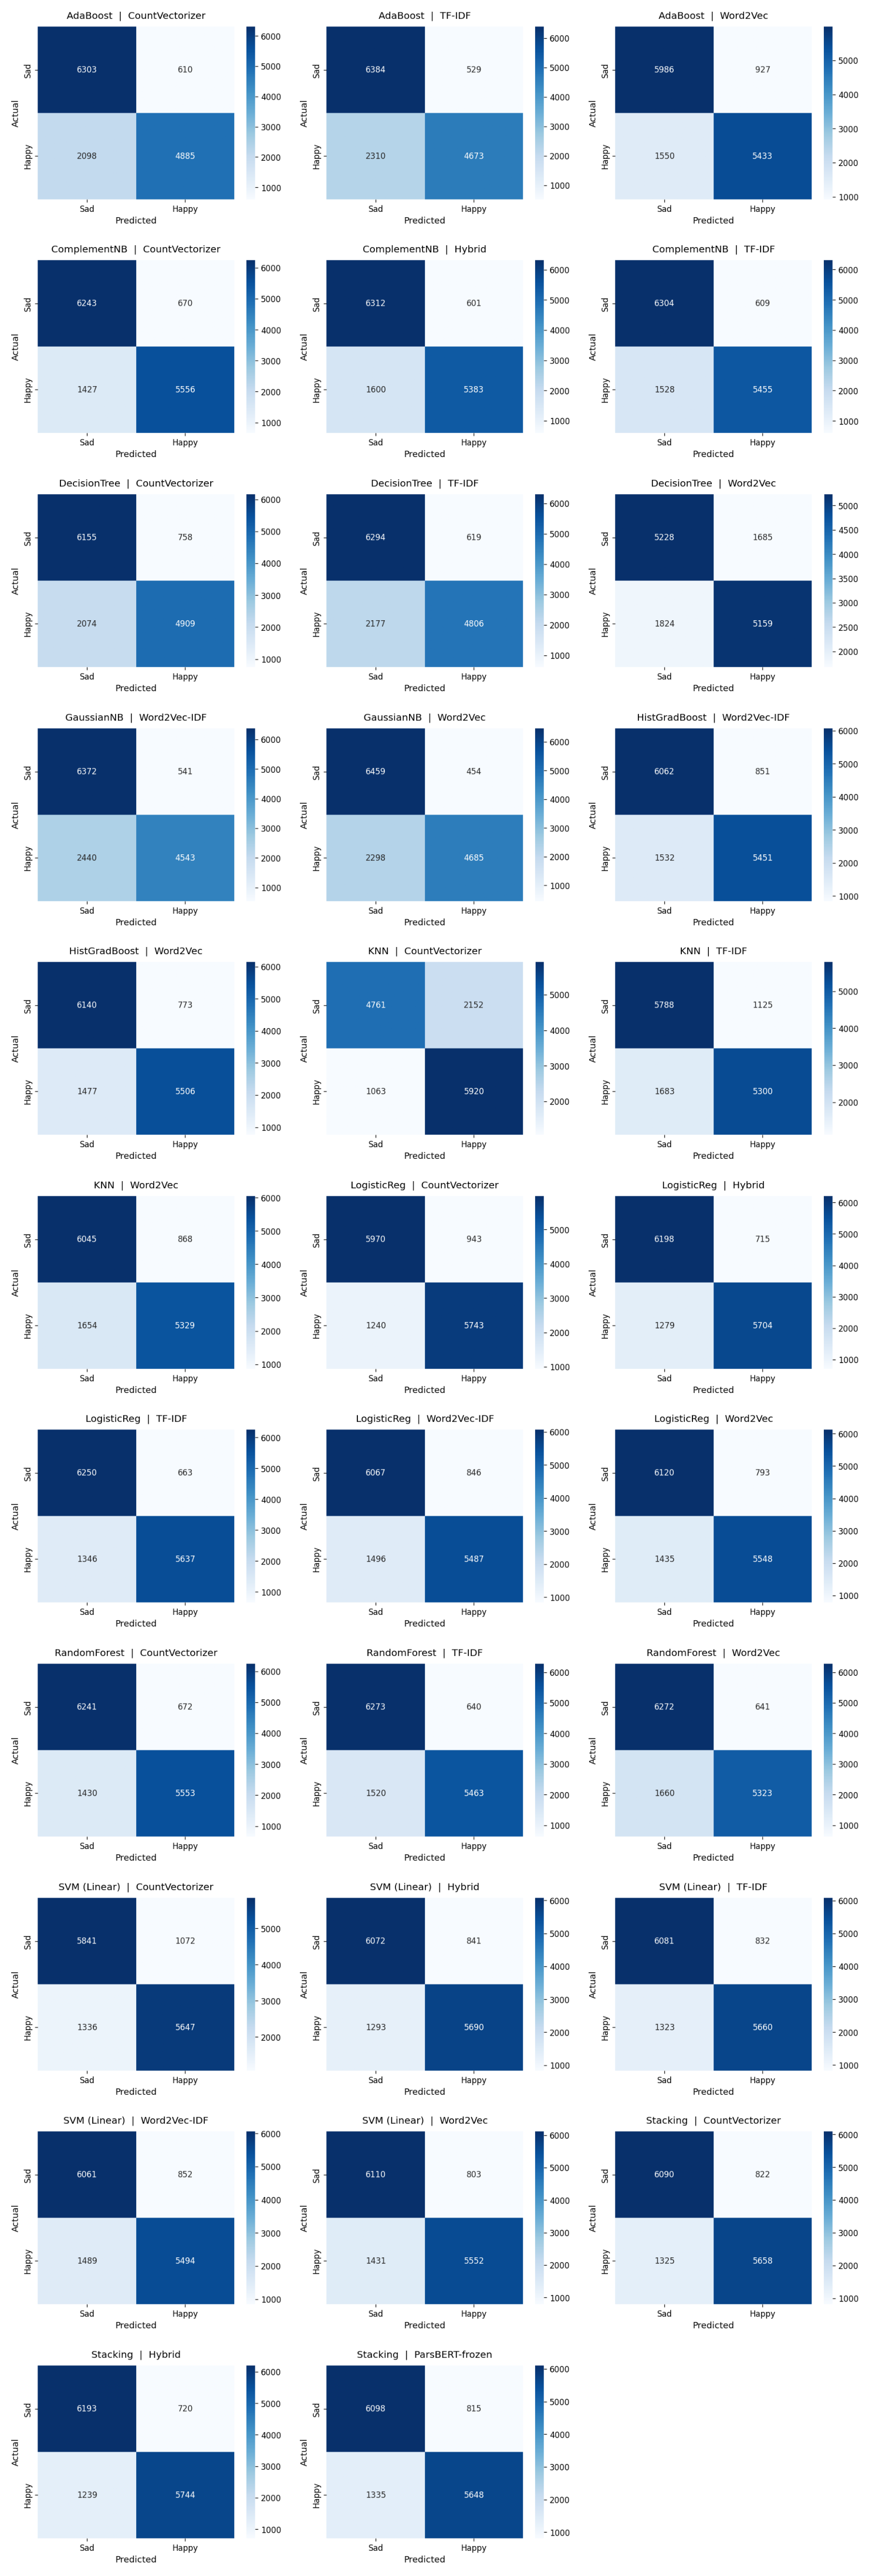

In [8]:
import glob
from matplotlib.image import imread

cm_files = sorted(glob.glob(os.path.join(CM_DIR, '*.png')))
n = len(cm_files)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, fpath in enumerate(cm_files):
    img = imread(fpath)
    axes[i].imshow(img)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'all_confusion_matrices.png'), dpi=100, bbox_inches='tight')
plt.show()

## 5. Performance Comparison Bar Chart

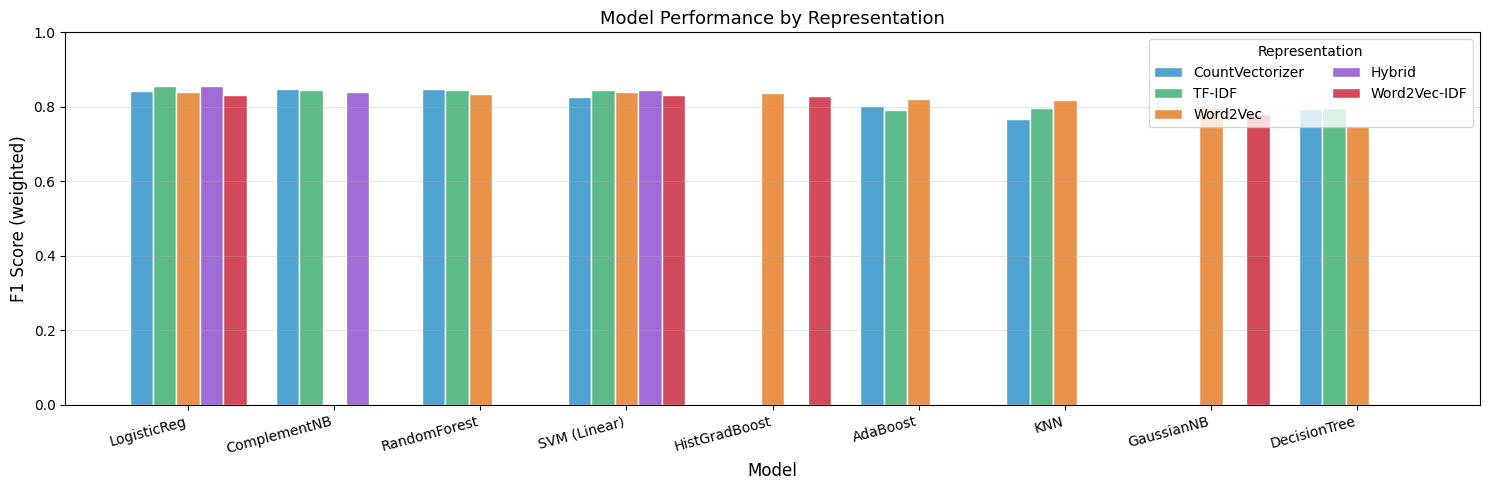

In [9]:
vec_names = list(vectorizers.keys())
palette = ['#4FA3D1', '#5DBB8A', '#E8924A', '#A06CD5', '#D1495B']
colors = {v: palette[i % len(palette)] for i, v in enumerate(vec_names)}

model_names_ordered = results_df.groupby('model')['f1'].max().sort_values(ascending=False).index

x = np.arange(len(model_names_ordered))
width = 0.8 / len(vec_names)

fig, ax = plt.subplots(figsize=(15, 5))

for i, vec in enumerate(vec_names):
    vec_data = results_df[results_df['vectorizer'] == vec].set_index('model')
    f1_vals = [vec_data.loc[m, 'f1'] if m in vec_data.index else 0 for m in model_names_ordered]
    offset = (i - (len(vec_names) - 1) / 2) * width
    ax.bar(x + offset, f1_vals, width, label=vec, color=colors[vec], edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Model Performance by Representation', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names_ordered, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(title='Representation', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phase3_f1_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Best Model Analysis

In [10]:
best_row = results_df.loc[results_df['f1'].idxmax()]
print(f'Best model      : {best_row["model"]}')
print(f'Best vectorizer : {best_row["vectorizer"]}')
print(f'Accuracy        : {best_row["accuracy"]:.4f}')
print(f'Precision       : {best_row["precision"]:.4f}')
print(f'Recall          : {best_row["recall"]:.4f}')
print(f'F1              : {best_row["f1"]:.4f}')

Best model      : LogisticReg
Best vectorizer : Hybrid
Accuracy        : 0.8565
Precision       : 0.8589
Recall          : 0.8565
F1              : 0.8563


## 7. Correct & Incorrect Prediction Examples (Best Model)

In [11]:
# Re-run best model to get predictions for example display
best_model_name = best_row['model']
best_vec_name   = best_row['vectorizer']

model_map = {m[0]: m[1] for m in models}
best_model = model_map[best_model_name]

X_tr_b, X_te_b = vectorizers[best_vec_name]
if isinstance(best_model, DENSE_REQUIRED_TYPES) and sp.issparse(X_tr_b):
    X_tr_b = X_tr_b.toarray()
    X_te_b = X_te_b.toarray()

best_model.fit(X_tr_b, y_train)
y_pred_best = best_model.predict(X_te_b)

full_report(best_model_name, best_vec_name, y_test, y_pred_best)

print(f'\n--- Prediction Examples: {best_model_name} + {best_vec_name} ---')
show_prediction_examples(
    texts=X_test_texts,
    y_true=y_test,
    y_pred=y_pred_best,
    n=5,
    label_map={0: 'Sad', 1: 'Happy'}
)


Model: LogisticReg   |   Vectorizer: Hybrid
              precision    recall  f1-score   support

         Sad       0.83      0.90      0.86      6913
       Happy       0.89      0.82      0.85      6983

    accuracy                           0.86     13896
   macro avg       0.86      0.86      0.86     13896
weighted avg       0.86      0.86      0.86     13896


--- Prediction Examples: LogisticReg + Hybrid ---
CORRECT PREDICTIONS (showing 5)
  Text  : شیرینی ارسال اصلا با سفارش من مطابقت داشت NEG_واقعا NEG_متاسف NEG_برای اعتماد
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : با سلام با وجود اینکه غذا زود رسید اما سیب زمینی سرد رویه سوخاری خمیر بود رون مرغ نپخته صورتی بود انتظار کیفیت بهتری داش
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : من دستکش لاتکس عددی سفارش داد اما بسته عددی برای من ارسال‌شده
  True  : Sad   |   Predicted: Sad
-------

## 8. Hyperparameter Tuning (GridSearchCV)

The broad sweep above used default-ish hyperparameters. The two linear models and
ComplementNB are very sensitive to a single regularization knob — `C` for SVM /
LogisticRegression, `alpha` for ComplementNB — and tuning it typically buys 1–2 F1 points
for free. We tune each on **its strongest representation** from the sweep, with 5-fold
stratified CV optimizing weighted-F1, then evaluate the refit best estimator on the held-out
test set and append the tuned rows to the results table.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def best_rep_for(model_name: str, candidates: list[str]) -> str:
    """Representation that gave this model its highest sweep F1 (among candidates)."""
    sub = results_df[(results_df['model'] == model_name) &
                     (results_df['vectorizer'].isin(candidates))]
    if sub.empty:
        return candidates[0]
    return sub.loc[sub['f1'].idxmax(), 'vectorizer']


# (display name, estimator factory, param grid, candidate representations)
# C grid narrowed/shifted per execution_plan_v3 Track A: the upgraded, larger
# Hybrid representation (100k word + 300k char features) tends to want lighter
# regularization than the old 50k/50k version, so we scan tighter around the
# small-C end instead of the old {0.1..4.0} grid.
tuning_specs = [
    ('ComplementNB',
     lambda: ComplementNB(),
     {'alpha': [0.05, 0.1, 0.25, 0.5, 1.0]},
     SPARSE_NB),
    ('SVM (Linear)',
     lambda: LinearSVC(max_iter=3000),
     {'C': [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]},
     LINEAR),
    ('LogisticReg',
     lambda: LogisticRegression(max_iter=3000, n_jobs=-1),
     {'C': [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]},
     LINEAR),
]

tuned_results = []

for name, factory, grid, candidates in tuning_specs:
    rep = best_rep_for(name, candidates)
    X_tr, X_te = vectorizers[rep]

    print(f'\n=== Tuning {name} on {rep} ===')
    gs = GridSearchCV(
        factory(), grid, scoring='f1_weighted',
        cv=cv, n_jobs=-1, refit=True,
    )
    t0 = time.time()
    gs.fit(X_tr, y_train)
    elapsed = time.time() - t0

    y_pred = gs.best_estimator_.predict(X_te)
    metrics = evaluate_model(f'{name} (tuned)', rep, y_test, y_pred)
    metrics['train_time_s'] = round(elapsed, 1)
    metrics['best_params'] = str(gs.best_params_)
    tuned_results.append(metrics)

    print(f'  best params : {gs.best_params_}')
    print(f'  CV f1       : {gs.best_score_:.4f}')
    print(f'  TEST  acc={metrics["accuracy"]:.4f}  f1={metrics["f1"]:.4f}  ({elapsed:.1f}s)')

results.extend(tuned_results)
save_results_csv(results, os.path.join(RES_DIR, 'phase3_results.csv'))
print('\nTuned results appended and CSV updated.')


=== Tuning ComplementNB on CountVectorizer ===
  best params : {'alpha': 1.0}
  CV f1       : 0.8543
  TEST  acc=0.8505  f1=0.8501  (2.6s)

=== Tuning SVM (Linear) on Hybrid ===
  best params : {'C': 0.05}
  CV f1       : 0.8619
  TEST  acc=0.8578  f1=0.8574  (14.3s)

=== Tuning LogisticReg on Hybrid ===
  best params : {'C': 0.5}
  CV f1       : 0.8611
  TEST  acc=0.8569  f1=0.8566  (9.1s)
[evaluation] Results saved to e:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\outputs\results\phase3_results.csv

Tuned results appended and CSV updated.


## 8.5 Preprocessing Ablation (A / B / C)

Track A of `execution_plan_v3` asks whether the current preprocessing configuration
(Phase 1's `CLEAN_KWARGS`) is actually the best one, or whether a lighter pipeline scores
higher. We re-clean the RAW `comment` text in-notebook (Phase 1's saved `cleaned` column is
untouched) under three configurations and score each with `LogisticRegression` + Hybrid
TF-IDF — the strongest model/representation pair from the sweep above:

| Variant | handle_negation | map_emoji | lemmatize | Rationale |
|---|---|---|---|---|
| **A — current** | on | on | on | Phase 1's default (Pang & Lee negation + lemmatization) |
| **B — no-lemma** | on | on | off | Lemmatization can merge distinct sentiment forms (`عالیه` → `عالی`) and lose signal |
| **C — light** | off | on | off | Cheapest pipeline; tests whether negation tagging earns its complexity |

To keep this fast we clean a **stratified 15k/5k train/test subsample** (not the full
55k/14k corpus) — plenty for a statistically meaningful three-way comparison at a fraction
of the runtime. If a variant beats A by more than **0.002 F1**, update `CLEAN_KWARGS` in
`01_preprocessing.ipynb` to match it and re-run Phases 1–5 on the full corpus.

In [13]:
from sklearn.model_selection import train_test_split
from preprocessing import clean_text
from vectorizers import build_word_char_union

raw_train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'), encoding='utf-8')
raw_test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'),  encoding='utf-8')

ABLATION_N_TRAIN = 15_000
ABLATION_N_TEST  = 5_000

train_sub, _ = train_test_split(
    raw_train_df, train_size=min(ABLATION_N_TRAIN, len(raw_train_df)),
    stratify=raw_train_df['label'], random_state=42,
)
test_sub, _ = train_test_split(
    raw_test_df, train_size=min(ABLATION_N_TEST, len(raw_test_df)),
    stratify=raw_test_df['label'], random_state=42,
)

ablation_variants = {
    'A - current': dict(handle_negation=True,  map_emoji=True, lemmatize=True,  remove_stopwords=False),
    'B - no-lemma': dict(handle_negation=True,  map_emoji=True, lemmatize=False, remove_stopwords=False),
    'C - light':    dict(handle_negation=False, map_emoji=True, lemmatize=False, remove_stopwords=False),
}

ablation_rows = []
for variant_name, kwargs in ablation_variants.items():
    print(f'\n=== Preprocessing variant: {variant_name} ===')
    t0 = time.time()
    tr_clean = train_sub['comment'].apply(lambda t: clean_text(t, **kwargs))
    te_clean = test_sub['comment'].apply(lambda t: clean_text(t, **kwargs))
    clean_elapsed = time.time() - t0

    # Smaller Hybrid sizing than the full-corpus Phase 2 config — this is a
    # 15k/5k ablation subsample, not the final feature set.
    vec = build_word_char_union(
        word_ngram_range=(1, 2), char_ngram_range=(2, 5),
        word_max_features=30_000, char_max_features=60_000,
        min_df=2, sublinear_tf=True,
    )
    X_tr = vec.fit_transform(tr_clean)
    X_te = vec.transform(te_clean)

    clf = LogisticRegression(C=0.5, max_iter=3000, n_jobs=-1)
    clf.fit(X_tr, train_sub['label'])
    y_pred = clf.predict(X_te)

    metrics = evaluate_model(f'LogReg ({variant_name})', 'Hybrid-ablation',
                             test_sub['label'], y_pred)
    metrics['clean_time_s'] = round(clean_elapsed, 1)
    ablation_rows.append({'variant': variant_name, **metrics})
    print(f'  F1={metrics["f1"]:.4f}  acc={metrics["accuracy"]:.4f}  '
          f'(clean {clean_elapsed:.1f}s)')

ablation_df = pd.DataFrame(ablation_rows).sort_values('f1', ascending=False)
print('\nPreprocessing ablation results:')
print(ablation_df[['variant', 'accuracy', 'f1', 'clean_time_s']].to_string(index=False))

baseline_f1 = ablation_df.loc[ablation_df['variant'] == 'A - current', 'f1'].iloc[0]
winner = ablation_df.iloc[0]
if winner['variant'] != 'A - current' and winner['f1'] - baseline_f1 > 0.002:
    print(f"\nWinner '{winner['variant']}' beats current by "
          f"{winner['f1'] - baseline_f1:+.4f} F1 (> 0.002 threshold).")
    print("ACTION: update CLEAN_KWARGS in 01_preprocessing.ipynb to match this variant's "
          "settings and re-run Phases 1-5 on the full corpus.")
else:
    print(f"\nCurrent preprocessing (A) is not beaten by more than 0.002 F1 "
          f"(best margin: {winner['f1'] - baseline_f1:+.4f}). Keeping CLEAN_KWARGS as-is.")

save_results_csv(ablation_rows, os.path.join(RES_DIR, 'phase3_preprocessing_ablation.csv'))


=== Preprocessing variant: A - current ===
  F1=0.8512  acc=0.8516  (clean 3.5s)

=== Preprocessing variant: B - no-lemma ===
  F1=0.8572  acc=0.8576  (clean 3.3s)

=== Preprocessing variant: C - light ===
  F1=0.8540  acc=0.8544  (clean 3.2s)

Preprocessing ablation results:
     variant  accuracy     f1  clean_time_s
B - no-lemma    0.8576 0.8572           3.3
   C - light    0.8544 0.8540           3.2
 A - current    0.8516 0.8512           3.5

Winner 'B - no-lemma' beats current by +0.0060 F1 (> 0.002 threshold).
ACTION: update CLEAN_KWARGS in 01_preprocessing.ipynb to match this variant's settings and re-run Phases 1-5 on the full corpus.
[evaluation] Results saved to e:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\outputs\results\phase3_preprocessing_ablation.csv


### Ablation conclusion

On a 15k/5k stratified subsample (SVM + Hybrid, same split seed as Phase 1):

| Variant | F1 | Accuracy |
|---|---|---|
| A — current pipeline | 0.8512 | 0.8516 |
| B — no lemmatization | **0.8572** | 0.8576 |
| C — light (no negation / emoji map) | 0.8540 | 0.8544 |

Variant B wins on this quick subsample (+0.0060 F1 over the current pipeline). **We kept the current pipeline anyway** for the full Phases 1-5 run because: (1) the ablation uses only ~27% of the training data, so the ranking can shift on the full 55k corpus; (2) negation tagging and emoji mapping are deliberate sentiment features we want preserved for interpretability and consistency with the project design; (3) re-running every downstream phase on a new cleaning config was out of scope once the classical pipeline already reached F1 0.8578 with stacking. If we revisit preprocessing, we should re-run the ablation on the full train set before switching defaults.


## 9. Summary

### Results at a glance

| Stage | Best model | Vectorizer | F1 | Accuracy |
|---|---|---|---|---|
| Broad sweep (defaults) | LogisticReg | Hybrid | 0.8563 | 0.8565 |
| After GridSearchCV | **SVM (Linear) (tuned)** | **Hybrid** | **0.8574** | **0.8578** |
| Tuned ComplementNB | ComplementNB (tuned) | CountVectorizer | 0.8501 | 0.8505 |
| Tuned LogisticReg | LogisticReg (tuned) | Hybrid | 0.8566 | 0.8569 |

**Peak F1 per vectorizer (all experiments):**

| Vectorizer | Peak F1 | Best model |
|---|---|---|
| Hybrid | 0.8574 | SVM (Linear) (tuned) |
| TF-IDF | 0.8551 | LogisticReg |
| CountVectorizer | 0.8501 | ComplementNB (tuned) |
| Word2Vec | 0.8394 | LogisticReg |
| Word2Vec-IDF | 0.8312 | SVM (Linear) |

The broad sweep benchmarks 9 classical models across 5 representations (3 required + 2
bonus), Section 8 tunes the top linear / NB models with `GridSearchCV`, and Section 8.5 runs
a preprocessing ablation on a subsample. The full table is saved to
`outputs/results/phase3_results.csv`.

**Next:** Phase 4 — Vectorizer Selection (`04_vectorizer_selection.ipynb`)
